In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

from src.curves.discount_curve import DiscountCurve
from src.curves.curve_shocks import CurveShocks

from src.instruments.fixed_rate_loan import FixedRateLoan
from src.instruments.floating_rate_loan import FloatingRateLoan
from src.instruments.interest_rate_swap import IRSwap

from src.risk.eve_engine import EVEEngine
from src.risk.nii_engine import NIIEngine

from src.behavioral.nmd_model import NMDModel

from src.hedging.optimizer import HedgeOptimizer
from src.hedging.swaps import Hedge_Tenors
from src.hedging.hedge_builder import build_hedge_swaps
from src.hedging.irrbb_optimizer import IRRBBOptimizer

In [2]:
# convert curve into long format
def prepare_curve_for_irrbb(
        curve_df: pd.DataFrame,
        valuation_date: datetime
) -> pd.DataFrame:
    """ 
    Select closest available curve before valuation date 
    and convert historical yield curve dataset into
    single curve into long format (tenor, rate)
    """
    
    curve_df['Date'] = pd.to_datetime(curve_df['Date'])

    # step 1: keep the curve dataset before valuation date
    curve_hist = curve_df.loc[
        curve_df['Date'] <= valuation_date
    ]

    if curve_hist.empty:
        raise ValueError("No curve available before valuation date!")
    
    # step 2: pick latest available curve before valuation date
    latest_curve = curve_hist.sort_values('Date').iloc[-1].copy()

    # step 3: drop date column
    latest_curve = latest_curve.drop('Date')

    # step 4: wide into long format
    curve_long = (
            latest_curve
            .rename_axis('tenor_label')
            .reset_index(name = 'rate')
    )

    tenor_map = {
        "1M": 1/12,
        "3M": 3/12,
        "6M": 6/12,
        "1Y": 1,
        "2Y": 2,
        "5Y": 5,
        "10Y": 10,
        "30Y": 30
    }

    curve_long['tenor'] = curve_long['tenor_label'].map(tenor_map)
    curve_long = curve_long.loc[:, ['tenor', 'rate']].sort_values('tenor')
    curve_long = curve_long.rename(
        columns = {
            'tenor': 'tenor_years',
            'rate': 'zero_rate'
        }
    )
    curve_long['zero_rate'] = curve_long['zero_rate'].astype('float')

    return curve_long

In [3]:
# loading yield curve
zero_curve = pd.read_csv('../data/processed/yield_curve_clean.csv')

# initiate valuation date
valuation_date = datetime(2026, 3, 1)

# convert zero curve into long format
zero_curve_long = prepare_curve_for_irrbb(
    curve_df = zero_curve,
    valuation_date = valuation_date
)

zero_curve_long

,tenor_years,zero_rate
0,0.083333,0.0374
1,0.250000,0.0367
2,0.500000,0.0360
3,1.000000,0.0348
4,2.000000,0.0338
5,5.000000,0.0351
6,10.000000,0.0397
7,30.000000,0.0464


In [4]:
# initiate discount curve
base_dc = DiscountCurve(zero_curve_long)

# generate Basel shock scenarios
shock_engine = CurveShocks(zero_curve_long)
shocked_curves = shock_engine.generate_all_scenarios()

# shocked discount curves
shocked_dc = {
    name: DiscountCurve(curve)
    for name, curve in shocked_curves.items()
}

In [5]:
### bank balance sheet
# assets
fixed_loans = [
    FixedRateLoan(
        notional = 650000,
        start_date = '2026-03-01',
        maturity_date = '2041-03-01',
        fixed_rate = 0.054,
        payment_frequency = 'M' 
    ),
    FixedRateLoan(
        notional = 480000,
        start_date = '2026-03-01',
        maturity_date = '2046-03-01',
        fixed_rate = 0.057,
        payment_frequency = 'M' 
    )
]

floating_loans = [
    FloatingRateLoan(
        notional = 740000,
        spread = 0.012,
        maturity_years = 5,
        payments_per_year = 2
    ),
    FloatingRateLoan(
        notional = 360000,
        spread = 0.009,
        maturity_years = 3,
        payments_per_year = 4
    )
]

# swaps
hedge_swap = [
    IRSwap(
        notional = 1500000,
        fixed_rate = 0.035,
        maturity_years = 5,
        payments_per_year = 4
    )
]

# liabilities
nmd = NMDModel(
    balance = 2400000,
    product_type = 'retail_savings',
    core_ratio = 0.80,
    avg_life_years = 5,
    beta = 0.3 
)

In [6]:
# compute base EVE and NII metrics
eve_engine = EVEEngine(
    discount_curve = base_dc,
    valuation_date = valuation_date
)

nii_engine = NIIEngine(
    valuation_date = valuation_date
)

base_eve = eve_engine.compute_eve_from_instruments(
    fixed_loans = fixed_loans,
    floating_loans = floating_loans,
    nmd_model = nmd
)

base_nii = nii_engine.compute_nii_from_instruments(
    fixed_loans = fixed_loans,
    floating_loans = floating_loans,
    nmd_model = nmd,
    discount_curve = base_dc,
    rate_shock = 0
)

print(f"Base EVE: {float(base_eve):.2f}")
print(f"Base NII: {float(base_nii):.2f}")

Base EVE: 485037.81
Base NII: 131172.58


In [7]:
# pre-hedge IRRBB Basel shock scenarios
pre_hedge_results = []

for scenario, shocked_curve in shocked_dc.items():

    # EVE
    eve_engine_pre_hedge_shocked = EVEEngine(
        discount_curve = shocked_curve,
        valuation_date = valuation_date
    )

    shocked_eve_pre_hedge = eve_engine_pre_hedge_shocked.compute_eve_from_instruments(
        fixed_loans = fixed_loans,
        floating_loans = floating_loans,
        nmd_model = nmd,
        swaps = None
    )

    delta_eve_pre_hedge = shocked_eve_pre_hedge - base_eve

    # NII
    nii_engine_pre_hedge_shocked = NIIEngine(
        valuation_date = valuation_date,
        payments_per_year = 4
    )
    
    rate_shock = (
        shocked_curve.curve.loc[shocked_curve.curve['tenor_years'] == 1, 'zero_rate'].values[0]
        - base_dc.curve.loc[base_dc.curve['tenor_years'] == 1, 'zero_rate'].values[0]
    )

    shocked_nii_pre_hedge = nii_engine_pre_hedge_shocked.compute_nii_from_instruments(
        fixed_loans = fixed_loans,
        floating_loans = floating_loans,
        nmd_model = nmd,
        discount_curve = shocked_curve,
        rate_shock = rate_shock,
        swaps = None
    )

    delta_nii_pre_hedge = shocked_nii_pre_hedge - base_nii

    pre_hedge_results.append([
        scenario,
        round(float(delta_eve_pre_hedge), 2),
        round(float(delta_nii_pre_hedge), 2)
    ])

# Pre-Hedge IRRBB report table
pre_hedge_irrbb_report = pd.DataFrame(
    pre_hedge_results,
    columns = [
        'Scenario',
        'Pre_Hedge_Delta_EVE',
        'Pre_Hedge_Delta_NII'
    ]
).set_index('Scenario')

# Tier 1 capital check
tier1_capital = 6e5

pre_hedge_irrbb_report['EVE_ratio'] = pre_hedge_irrbb_report['Pre_Hedge_Delta_EVE'].abs() / tier1_capital
pre_hedge_irrbb_report['Basel_Breach'] = pre_hedge_irrbb_report['EVE_ratio'] > 0.15

pre_hedge_irrbb_report

,Pre_Hedge_Delta_EVE,Pre_Hedge_Delta_NII,EVE_ratio,Basel_Breach
Scenario,,,,
parallel_up,-75024.69,66000.0,0.125041,False
parallel_down,104031.74,-66000.0,0.173386,True
short_up,-64348.55,82500.0,0.107248,False
short_down,83809.34,-82500.0,0.139682,False
steepener,15316.77,-33000.0,0.025528,False
flattener,-14259.44,33000.0,0.023766,False


In [8]:
### post-hedge IRRBB Basel shock scenarios
# initiate irrbb optimizer object
irrbb_optimizer = IRRBBOptimizer(
    base_curve_df = base_dc.curve,
    shocked_curves = shocked_curves,
    fixed_loans = fixed_loans,
    floating_loans = floating_loans,
    nmd_model = nmd,
    valuation_date = valuation_date,
    w_eve = 1.0,
    w_nii = 0.4,
    lambda_reg = 1e-10,
    hedge_budget = 1e7
)

# compute optimal notionals vector
optimal_notionals_vec = irrbb_optimizer.optimize()
print(optimal_notionals_vec)

# hedge report for optimal notionals per tenor
irrbb_optimizer.hedge_report(
    opt_notionals = optimal_notionals_vec
)

# build IR swaps from suggested hedge trades
hedge_swaps = irrbb_optimizer._build_hedge_swaps(
    optimal_notionals = optimal_notionals_vec
)

print(f"\nNumber of hedge swaps created: {len(hedge_swaps)}")

# hedge diagnostics for optimal notionals
irrbb_optimizer.hedge_diagnostics(
    opt_notionals = optimal_notionals_vec 
)

[-8.83569616e-01 -1.44840251e+01  5.04670798e+01 -1.59258930e+02
 -3.10224464e+03  2.64402965e+05]

--- Recommended Hedge Trades ---

Total hedge notionals used: 267,730
Budget limit: 10,000,000

Receive Fixed   0.0000m 1Y swap
Receive Fixed   0.0000m 2Y swap
Pay Fixed      0.0001m 5Y swap
Receive Fixed   0.0002m 10Y swap
Receive Fixed   0.0031m 20Y swap
Pay Fixed      0.2644m 30Y swap

Number of hedge swaps created: 6

--- Hedge Diagnostics ---

EVE risk component: 158,164,910.58
NII risk component: 33,099,205,643.85
Regularization: 6.99
Objective value: 13,397,847,175.11


In [ ]:
# post-hedge IRRBB simulation
post_hedge_results = []

# recomputing base EVE & NII with optimal hedge swaps
eve_engine_base_opt_notionals = EVEEngine(
    discount_curve = base_dc,
    valuation_date = valuation_date
)

nii_engine_base_opt_notionals = NIIEngine(
    valuation_date = valuation_date
)

base_eve_opt_notionals = eve_engine_base_opt_notionals.compute_eve_from_instruments(
    fixed_loans = fixed_loans,
    floating_loans = floating_loans,
    nmd_model = nmd,
    swaps = hedge_swaps 
)

base_nii_opt_notionals = nii_engine_base_opt_notionals.compute_nii_from_instruments(
    fixed_loans = fixed_loans,
    floating_loans = floating_loans,
    nmd_model = nmd,
    discount_curve = base_dc,
    rate_shock = 0,
    swaps = hedge_swaps
)

for scenario, shocked_curve in shocked_dc.items():

    # EVE
    eve_engine_post_hedge_shocked = EVEEngine(
        discount_curve = shocked_curve,
        valuation_date = valuation_date
    )

    shocked_eve_post_hedge = eve_engine_post_hedge_shocked.compute_eve_from_instruments(
        fixed_loans = fixed_loans,
        floating_loans = floating_loans,
        nmd_model = nmd,
        swaps = hedge_swaps
    )

    delta_eve_post_hedge = shocked_eve_post_hedge - base_eve_opt_notionals

    # NII
    nii_engine_post_hedge_shocked = NIIEngine(
        valuation_date = valuation_date
    )

    rate_shock = (
        shocked_curve.curve.loc[shocked_curve.curve['tenor_years'] == 1, 'zero_rate'].values[0]
        - base_dc.curve.loc[base_dc.curve['tenor_years'] == 1, 'zero_rate'].values[0]
    )

    shocked_nii_post_hedge = nii_engine_post_hedge_shocked.compute_nii_from_instruments(
        fixed_loans = fixed_loans,
        floating_loans = floating_loans,
        nmd_model = nmd,
        discount_curve = shocked_curve,
        rate_shock = rate_shock,
        swaps = hedge_swaps
    )

    delta_nii_post_hedge = shocked_nii_post_hedge - base_nii_opt_notionals

    post_hedge_results.append([
        scenario,
        round(float(delta_eve_post_hedge), 2),
        round(float(delta_nii_post_hedge), 2)
    ])

# Post-Hedge IRRBB report table
post_hedge_irrbb_report = pd.DataFrame(
    post_hedge_results,
    columns = [
        'Scenario',
        'Post_Hedge_Delta_EVE',
        'Post_Hedge_Delta_NII'
    ]
).set_index('Scenario')

# Tier 1 capital check
tier1_capital = 6e5

post_hedge_irrbb_report['EVE_ratio'] = post_hedge_irrbb_report['Post_Hedge_Delta_EVE'].abs() / tier1_capital
post_hedge_irrbb_report['Basel_Breach'] = post_hedge_irrbb_report['EVE_ratio'] > 0.15

post_hedge_irrbb_report

,Post_Hedge_Delta_EVE,Post_Hedge_Delta_NII,EVE_ratio,Basel_Breach
Scenario,,,,
parallel_up,-6946.04,76709.21,0.011577,False
parallel_down,620.44,-76709.21,0.001034,False
short_up,-7221.27,95886.52,0.012035,False
short_down,6190.93,-95886.52,0.010318,False
steepener,3254.75,-38354.61,0.005425,False
flattener,-2909.40,38354.61,0.004849,False


,Pre_Hedge_Delta_EVE,Pre_Hedge_Delta_NII,Post_Hedge_Delta_EVE,Post_Hedge_Delta_NII
Scenario,,,,
parallel_up,-75025.0,66000.0,-6946.0,76709.0
parallel_down,104032.0,-66000.0,620.0,-76709.0
short_up,-64349.0,82500.0,-7221.0,95887.0
short_down,83809.0,-82500.0,6191.0,-95887.0
steepener,15317.0,-33000.0,3255.0,-38355.0
flattener,-14259.0,33000.0,-2909.0,38355.0


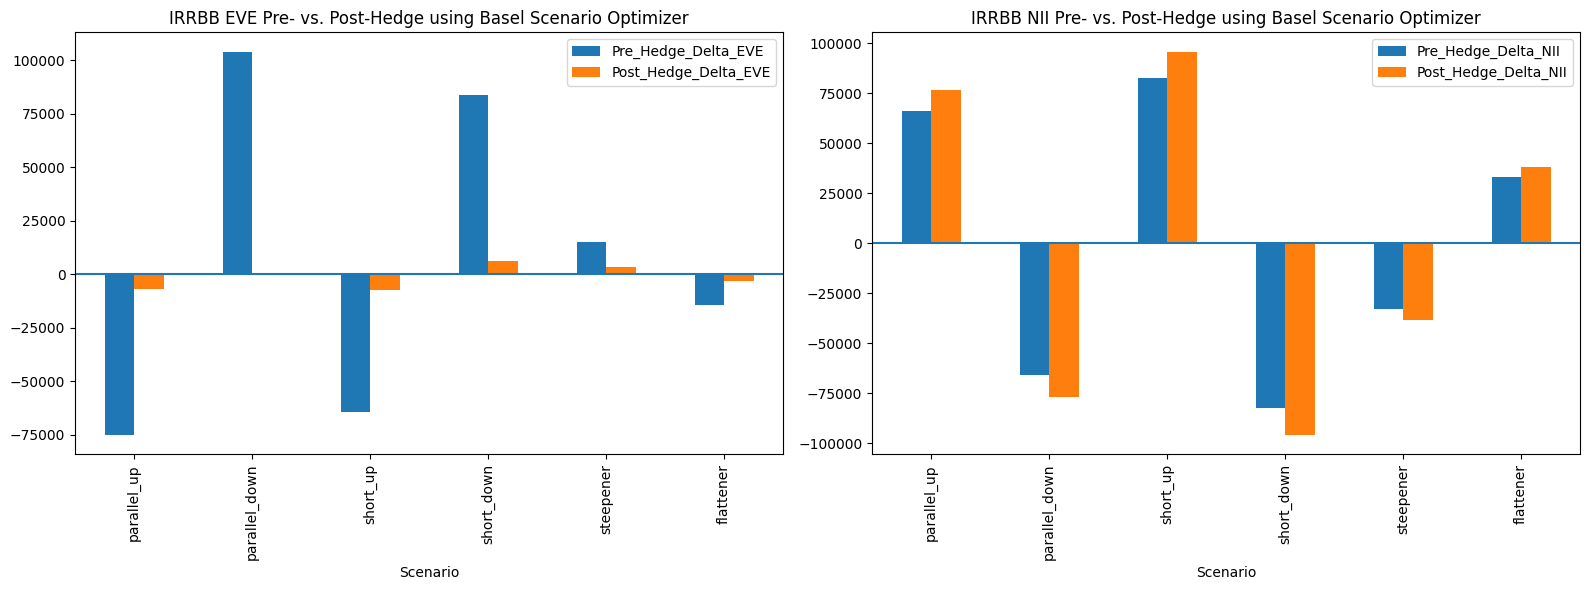

In [10]:
# comparing pre- vs post-hedge results
df_compare = pre_hedge_irrbb_report[['Pre_Hedge_Delta_EVE', 'Pre_Hedge_Delta_NII']].join(post_hedge_irrbb_report[['Post_Hedge_Delta_EVE', 'Post_Hedge_Delta_NII']])

display(df_compare.round(0))

# plotting pre- vs post-hedge scenarios
fig, axes = plt.subplots(1, 2, figsize = (16, 6))

df_compare[['Pre_Hedge_Delta_EVE', 'Post_Hedge_Delta_EVE']].plot(
    kind = 'bar',
    title = 'IRRBB EVE Pre- vs. Post-Hedge using Basel Scenario Optimizer',
    ax = axes[0]
)

axes[0].axhline(0)

df_compare[['Pre_Hedge_Delta_NII', 'Post_Hedge_Delta_NII']].plot(
    kind = 'bar',
    title = 'IRRBB NII Pre- vs. Post-Hedge using Basel Scenario Optimizer',
    ax = axes[1]
)

axes[1].axhline(0)

plt.tight_layout()
plt.show()